# Photo-z CNN v6 — Interprétations + Limites de prédiction
# Fait par Maximiliano RUIZ


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, gc, glob, copy
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

appareil = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil : {appareil}")
if appareil.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
torch.backends.cudnn.benchmark = True

def statut_ram(etiquette=""):
    r = psutil.virtual_memory()
    print(f"[RAM {etiquette}] {r.used/1e9:.2f} Go / {r.total/1e9:.2f} Go ({r.percent:.1f}%)")

statut_ram("démarrage")

Appareil : cuda
GPU      : Tesla T4
[RAM démarrage] 2.02 Go / 13.61 Go (17.3%)


## 2. Chargement des données COSMOS

In [ ]:
dossier = "/content/drive/MyDrive/redshift"
os.chdir(dossier)
fichiers_npz    = glob.glob("*.npz")
fichiers_cosmos = [f for f in fichiers_npz if "COSMOS" in f]
donnees_cosmos  = {}
for fichier in fichiers_cosmos:
    try:
        donnees_cosmos[fichier] = np.load(fichier, allow_pickle=True)
        print(f"Chargé : {fichier}")
    except Exception as e:
        print(f"Erreur : {fichier} — {e}")
for nom, d in donnees_cosmos.items():
    print(f"\n=== {nom} ===")
    for cle in d.keys(): print(f"  - {cle} : {d[cle].shape}")
statut_ram("après chargement")

Chargé : COSMOS_v11_uijk_0001_photo_D.npz
Chargé : COSMOS_v11_uijk_0213_photo_UD.npz
Chargé : COSMOS_v11_uijk_0020_spec_D.npz
Chargé : COSMOS_v11_uijk_0073_spec_UD.npz

=== COSMOS_v11_uijk_0001_photo_D.npz ===
  - cube : (12054, 64, 64, 9)
  - info : (12054,)
  - flag : (12054, 9)

=== COSMOS_v11_uijk_0213_photo_UD.npz ===
  - cube : (443, 64, 64, 9)
  - info : (443,)
  - flag : (443, 9)

=== COSMOS_v11_uijk_0020_spec_D.npz ===
  - cube : (15, 64, 64, 9)
  - info : (15,)
  - flag : (15, 9)

=== COSMOS_v11_uijk_0073_spec_UD.npz ===
  - cube : (12, 64, 64, 9)
  - info : (12,)
  - flag : (12, 9)
[RAM après chargement] 1.97 Go / 13.61 Go (17.0%)


## 3. Combinaison et nettoyage

In [ ]:
fichiers_photo = [f for f in fichiers_npz if "photo" in f.lower()]
liste_info_photo, liste_cube_photo = [], []
for nom_fichier in fichiers_photo:
    d = donnees_cosmos[nom_fichier]
    liste_info_photo.append(d['info']); liste_cube_photo.append(d['cube'])

tous_enregistrements = []
for tableau_info in liste_info_photo:
    for enreg in tableau_info:
        tous_enregistrements.append({nom: enreg[nom] for nom in tableau_info.dtype.names})

df_photo_complet   = pd.DataFrame(tous_enregistrements)
cube_photo_complet = np.concatenate(liste_cube_photo, axis=0)
if 'ZPHOT' in df_photo_complet.columns:
    df_photo_complet = df_photo_complet.rename(columns={"ZPHOT": "redshift"})

magnitudes_base = ['u', 'g', 'r', 'i', 'z', 'y']
masque_valide   = ~df_photo_complet[magnitudes_base].apply(lambda col: (col < -90) | col.isna()).any(axis=1)
masque_valide  &= df_photo_complet['redshift'].notna()
df_photo_nettoye   = df_photo_complet[masque_valide].copy()
cube_photo_nettoye = cube_photo_complet[masque_valide].copy()
print(f"Après nettoyage : {cube_photo_nettoye.shape[0]} objets")
del tous_enregistrements, liste_info_photo, liste_cube_photo, cube_photo_complet, df_photo_complet
gc.collect()
statut_ram("après nettoyage")

Après nettoyage : 10437 objets
[RAM après nettoyage] 3.45 Go / 13.61 Go (27.6%)


## 4. Prétraitement

In [ ]:
images     = np.arcsinh(cube_photo_nettoye.astype(np.float32))
colonnes_mag = ['u', 'g', 'r', 'i', 'z', 'y']
magnitudes = df_photo_nettoye[colonnes_mag].values.astype(np.float32)
y          = df_photo_nettoye['redshift'].values.astype(np.float32)
del cube_photo_nettoye; gc.collect()

nb_bins = 150
y_binnise, bords_bins = pd.cut(y, bins=nb_bins, labels=False, include_lowest=True, retbins=True)
centres_bins = ((bords_bins[:-1] + bords_bins[1:]) / 2).astype(np.float32)
nb_classes   = nb_bins
y_binnise_grossier, _ = pd.cut(y, bins=20, labels=False, include_lowest=True, retbins=True)

print(f"Redshift : [{y.min():.3f}, {y.max():.3f}]")
print(f"Bins fins : {nb_bins}  (largeur ~{bords_bins[1]-bords_bins[0]:.4f} en z)")
statut_ram("avant séparation")

Redshift : [0.010, 5.788]
Bins fins : 150  (largeur ~0.0443 en z)
[RAM avant séparation] 3.47 Go / 13.61 Go (27.8%)


In [ ]:
(images_trval, images_test, mags_trval, mags_test,
 yb_trval, yb_test, yo_trval, yo_test,
 ybc_trval, ybc_test) = train_test_split(
    images, magnitudes, y_binnise, y, y_binnise_grossier,
    test_size=0.2, random_state=42, stratify=y_binnise_grossier)

(images_train, images_val, mags_train, mags_val,
 yb_train, yb_val, yo_train, yo_val,
 ybc_train, ybc_val) = train_test_split(
    images_trval, mags_trval, yb_trval, yo_trval, ybc_trval,
    test_size=0.25, random_state=42, stratify=ybc_trval)

del images, magnitudes, images_trval, mags_trval, yb_trval, yo_trval, ybc_trval
del ybc_train, ybc_val, ybc_test
gc.collect()
print(f"Train / Val / Test : {len(images_train)} / {len(images_val)} / {len(images_test)}")
statut_ram("après séparation")

Train / Val / Test : 6261 / 2088 / 2088
[RAM après séparation] 3.48 Go / 13.61 Go (27.8%)


In [ ]:
moyenne_bande = images_train.mean(axis=(0,1,2), keepdims=True)
ecart_bande   = images_train.std(axis=(0,1,2),  keepdims=True) + 1e-6
images_train  = ((images_train - moyenne_bande) / ecart_bande).astype(np.float16)
images_val    = ((images_val   - moyenne_bande) / ecart_bande).astype(np.float16)
images_test   = ((images_test  - moyenne_bande) / ecart_bande).astype(np.float16)

moyenne_mag = mags_train.mean(axis=0, keepdims=True)
ecart_mag   = mags_train.std(axis=0,  keepdims=True) + 1e-6
mags_train  = (mags_train - moyenne_mag) / ecart_mag
mags_val    = (mags_val   - moyenne_mag) / ecart_mag
mags_test   = (mags_test  - moyenne_mag) / ecart_mag
gc.collect(); statut_ram("après normalisation")

[RAM après normalisation] 2.70 Go / 13.61 Go (22.1%)


In [ ]:
SIGMA_DOUX = 2.0
def creer_labels_doux_gaussiens(y_binnise, nb_classes, sigma=2.0):
    bins  = np.arange(nb_classes, dtype=np.float32)[None, :]
    y_arr = y_binnise.reshape(-1, 1).astype(np.float32)
    poids = np.exp(-0.5 * ((bins - y_arr) / sigma) ** 2)
    return (poids / poids.sum(axis=1, keepdims=True)).astype(np.float32)

labels_doux_train = creer_labels_doux_gaussiens(yb_train, nb_classes, sigma=SIGMA_DOUX)
labels_doux_val   = creer_labels_doux_gaussiens(yb_val,   nb_classes, sigma=SIGMA_DOUX)
print(f"Labels doux — sigma={SIGMA_DOUX}, forme : {labels_doux_train.shape}")

Labels doux — sigma=2.0, forme : (6261, 150)


## 5. Dataset + DataLoaders

In [ ]:
t_images_train = torch.tensor(images_train, dtype=torch.float16).permute(0,3,1,2).contiguous()
t_images_val   = torch.tensor(images_val,   dtype=torch.float16).permute(0,3,1,2).contiguous()
t_images_test  = torch.tensor(images_test,  dtype=torch.float16).permute(0,3,1,2).contiguous()
t_mags_train   = torch.tensor(mags_train, dtype=torch.float32)
t_mags_val     = torch.tensor(mags_val,   dtype=torch.float32)
t_mags_test    = torch.tensor(mags_test,  dtype=torch.float32)
t_labels_doux_train = torch.tensor(labels_doux_train, dtype=torch.float32)
t_labels_doux_val   = torch.tensor(labels_doux_val,   dtype=torch.float32)
t_yb_train = torch.tensor(yb_train, dtype=torch.long)
t_yb_val   = torch.tensor(yb_val,   dtype=torch.long)
t_yb_test  = torch.tensor(yb_test,  dtype=torch.long)
t_yo_train = torch.tensor(yo_train, dtype=torch.float32)
t_yo_val   = torch.tensor(yo_val,   dtype=torch.float32)
del images_train, images_val, images_test, mags_train, mags_val, mags_test
del labels_doux_train, labels_doux_val
gc.collect(); statut_ram("après tenseurs")

[RAM après tenseurs] 2.69 Go / 13.61 Go (22.1%)


In [ ]:
class DatasetGalaxiesHybride(Dataset):
    def __init__(self, X_img, X_mag, y_doux, y_dur, y_flottant, augmentation=True):
        self.X_img=X_img; self.X_mag=X_mag; self.y_doux=y_doux
        self.y_dur=y_dur; self.y_flottant=y_flottant; self.augmentation=augmentation
    def __len__(self): return len(self.X_img)
    def __getitem__(self, idx):
        x_img=self.X_img[idx].float(); x_mag=self.X_mag[idx]
        y_d=self.y_doux[idx]; y_h=self.y_dur[idx]; y_f=self.y_flottant[idx]
        if self.augmentation:
            k=int(torch.randint(0,4,(1,)).item())
            if k>0: x_img=torch.rot90(x_img,k,dims=[1,2])
            if torch.rand(1).item()<0.5: x_img=torch.flip(x_img,dims=[1])
            if torch.rand(1).item()<0.5: x_img=torch.flip(x_img,dims=[2])
        return x_img, x_mag, y_d, y_h, y_f

dataset_train = DatasetGalaxiesHybride(t_images_train, t_mags_train, t_labels_doux_train, t_yb_train, t_yo_train, augmentation=True)
dataset_val   = DatasetGalaxiesHybride(t_images_val,   t_mags_val,   t_labels_doux_val,   t_yb_val,   t_yo_val,   augmentation=False)
chargeur_train = DataLoader(dataset_train, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
chargeur_val   = DataLoader(dataset_val,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
print("DataLoaders prêts.")

DataLoaders prêts.


## 6. Modèle hybride CNN + MLP

In [ ]:
class ModeleRedshiftHybride(nn.Module):
    def __init__(self, nb_canaux, haut_img, larg_img, nb_mag, nb_classes):
        super().__init__()
        self.couches_cnn = nn.Sequential(
            nn.Conv2d(nb_canaux,32,kernel_size=3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AvgPool2d(2,2), nn.Dropout(0.2),
            nn.Conv2d(32,64,kernel_size=3,padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.AvgPool2d(2,2), nn.Dropout(0.2),
            nn.Conv2d(64,128,kernel_size=3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AvgPool2d(2,2), nn.Dropout(0.2),
        )
        with torch.no_grad():
            factice = torch.randn(1, nb_canaux, haut_img, larg_img)
            taille_aplatie = self.couches_cnn(factice).numel()
        self.mlp_mag  = nn.Sequential(nn.Linear(nb_mag,32), nn.ReLU(), nn.Linear(32,32), nn.ReLU())
        taille_combinee = taille_aplatie + 32
        self.tete_cls = nn.Sequential(nn.Linear(taille_combinee,256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256,nb_classes))
        self.tete_reg = nn.Sequential(nn.Linear(taille_combinee,128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,1))
    def forward(self, img, mag):
        f=torch.cat([self.couches_cnn(img).reshape(img.size(0),-1), self.mlp_mag(mag)], dim=1)
        return self.tete_cls(f), self.tete_reg(f)

nb_canaux=9; haut_img=64; larg_img=64; nb_mag=6
_m = ModeleRedshiftHybride(nb_canaux, haut_img, larg_img, nb_mag, nb_classes)
print(f"Paramètres entraînables : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m

Paramètres entraînables : 3,293,783


## 7. Fonction d'entraînement

In [ ]:
def perte_entropie_croisee_douce(logits, cibles_douces):
    return -(cibles_douces * torch.log_softmax(logits, dim=1)).sum(dim=1).mean()

LAMBDA_REG   = 0.1
utiliser_amp = (appareil.type == 'cuda')

def entrainer_un_modele(graine=42, nb_epochs=200, patience=30, verbose=True):
    torch.manual_seed(graine); np.random.seed(graine)
    modele = ModeleRedshiftHybride(nb_canaux, haut_img, larg_img, nb_mag, nb_classes).to(appareil)
    optimiseur    = optim.AdamW(modele.parameters(), lr=5e-4, weight_decay=1e-4)
    planificateur = optim.lr_scheduler.ReduceLROnPlateau(optimiseur, mode='min', factor=0.5, patience=7)
    gradscaler    = torch.amp.GradScaler('cuda', enabled=utiliser_amp)
    meilleure_perte_val=float('inf'); compteur_patience=0; meilleur_etat=None
    pertes_train=[]; pertes_val=[]; precisions_train=[]; precisions_val=[]

    for epoch in range(nb_epochs):
        modele.train()
        perte_cumul=nb_corrects=nb_total=0
        for x_img, x_mag, y_doux, y_dur, y_fl in chargeur_train:
            x_img=x_img.to(appareil,non_blocking=True); x_mag=x_mag.to(appareil,non_blocking=True)
            y_doux=y_doux.to(appareil,non_blocking=True); y_dur=y_dur.to(appareil,non_blocking=True)
            y_fl=y_fl.to(appareil,non_blocking=True)
            optimiseur.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=utiliser_amp):
                sc, sr = modele(x_img, x_mag)
                perte  = perte_entropie_croisee_douce(sc, y_doux) + LAMBDA_REG*F.mse_loss(sr.squeeze(), y_fl)
            gradscaler.scale(perte).backward(); gradscaler.step(optimiseur); gradscaler.update()
            perte_cumul+=perte.item(); _,pred=torch.max(sc,1)
            nb_corrects+=(pred==y_dur).sum().item(); nb_total+=y_dur.size(0)
        pt=perte_cumul/len(chargeur_train); prec_t=nb_corrects/nb_total

        modele.eval()
        pvc=nvc=nvt=0
        with torch.no_grad():
            for x_img, x_mag, y_doux, y_dur, y_fl in chargeur_val:
                x_img=x_img.to(appareil,non_blocking=True); x_mag=x_mag.to(appareil,non_blocking=True)
                y_doux=y_doux.to(appareil,non_blocking=True); y_dur=y_dur.to(appareil,non_blocking=True)
                y_fl=y_fl.to(appareil,non_blocking=True)
                with torch.amp.autocast('cuda', enabled=utiliser_amp):
                    sc, sr = modele(x_img, x_mag)
                    pvc += (perte_entropie_croisee_douce(sc,y_doux)+LAMBDA_REG*F.mse_loss(sr.squeeze(),y_fl)).item()
                _,pred=torch.max(sc,1); nvc+=(pred==y_dur).sum().item(); nvt+=y_dur.size(0)
        pv=pvc/len(chargeur_val); prec_v=nvc/nvt
        pertes_train.append(pt); pertes_val.append(pv)
        precisions_train.append(prec_t); precisions_val.append(prec_v)
        planificateur.step(pv)
        if pv < meilleure_perte_val:
            meilleure_perte_val=pv; meilleur_etat=copy.deepcopy(modele.state_dict()); compteur_patience=0
        else: compteur_patience+=1
        if verbose and ((epoch+1)%5==0 or epoch==0):
            print(f"Epoch {epoch+1:3d} | Train P:{pt:.4f} Préc:{prec_t:.3f} | Val P:{pv:.4f} Préc:{prec_v:.3f} | lr:{optimiseur.param_groups[0]['lr']:.2e}")
        if compteur_patience>=patience: print(f"Arrêt anticipé epoch {epoch+1}"); break
        if (epoch+1)%10==0: torch.cuda.empty_cache(); gc.collect()

    if meilleur_etat: modele.load_state_dict(meilleur_etat); print("Meilleurs poids rechargés.")
    modele.eval(); liste_sm=[]; liste_reg=[]
    chargeur_test = DataLoader(TensorDataset(t_images_test, t_mags_test, t_yb_test), batch_size=64, shuffle=False)
    with torch.no_grad():
        for x_img, x_mag, _ in chargeur_test:
            x_img=x_img.float().to(appareil); x_mag=x_mag.to(appareil)
            with torch.amp.autocast('cuda', enabled=utiliser_amp):
                sc, sr = modele(x_img, x_mag)
            liste_sm.append(torch.softmax(sc.float(),dim=1).cpu().numpy())
            liste_reg.append(sr.float().cpu().numpy())
    return (modele, np.concatenate(liste_sm,axis=0), np.concatenate(liste_reg,axis=0).squeeze(),
            pertes_train, pertes_val, precisions_train, precisions_val)

print(f"Perte combinée : soft_CE + {LAMBDA_REG} × MSE_reg")

Perte combinée : soft_CE + 0.1 × MSE_reg


## 8. Ensemble de 2 modèles

In [ ]:
toutes_sorties_softmax=[]; toutes_sorties_reg=[]; historique_modeles=[]
GRAINES = [42, 99]
for i, graine in enumerate(GRAINES):
    print(f"\n{'='*55}\n  Modèle {i+1}/{len(GRAINES)} (graine={graine})\n{'='*55}")
    modele_i, sm_i, reg_i, pt_i, pv_i, prt_i, prv_i = entrainer_un_modele(graine=graine, nb_epochs=200, patience=30)
    toutes_sorties_softmax.append(sm_i); toutes_sorties_reg.append(reg_i)
    historique_modeles.append((pt_i, pv_i, prt_i, prv_i))
    del modele_i; torch.cuda.empty_cache(); gc.collect()
    statut_ram(f"après modèle {i+1}")

softmax_ensemble = np.mean(toutes_sorties_softmax, axis=0)
reg_ensemble     = np.mean(toutes_sorties_reg,     axis=0)
print(f"\nEnsemble prêt — {len(GRAINES)} modèles moyennés. Forme : {softmax_ensemble.shape}")


  Modèle 1/2 (graine=42)
Epoch   1 | Train P:4.5907 Préc:0.025 | Val P:4.2125 Préc:0.036 | lr:5.00e-04
Epoch   5 | Train P:3.4803 Préc:0.081 | Val P:3.3133 Préc:0.102 | lr:5.00e-04
Epoch  10 | Train P:3.2151 Préc:0.111 | Val P:3.1357 Préc:0.134 | lr:5.00e-04
Epoch  15 | Train P:3.1044 Préc:0.117 | Val P:3.0180 Préc:0.137 | lr:5.00e-04
Epoch  20 | Train P:3.0295 Préc:0.131 | Val P:2.9371 Préc:0.158 | lr:5.00e-04
Epoch  25 | Train P:2.9806 Préc:0.139 | Val P:2.9137 Préc:0.166 | lr:5.00e-04
Epoch  30 | Train P:2.9278 Préc:0.155 | Val P:2.8773 Préc:0.171 | lr:5.00e-04
Epoch  35 | Train P:2.9037 Préc:0.157 | Val P:2.8782 Préc:0.162 | lr:5.00e-04
Epoch  40 | Train P:2.8722 Préc:0.170 | Val P:2.8247 Préc:0.177 | lr:5.00e-04
Epoch  45 | Train P:2.8442 Préc:0.163 | Val P:2.8242 Préc:0.180 | lr:5.00e-04
Epoch  50 | Train P:2.8100 Préc:0.176 | Val P:2.7914 Préc:0.192 | lr:5.00e-04
Epoch  55 | Train P:2.7967 Préc:0.173 | Val P:2.7780 Préc:0.211 | lr:5.00e-04
Epoch  60 | Train P:2.7860 Préc:0.182 

### 💬 Interprétation — Courbes d'entraînement

**Ce qui s'est passé epoch par epoch :**

La perte est passée de ~4.6 (epoch 1) à ~2.7 (fin). Cette valeur finale peut sembler élevée, mais c'est **normal** : avec des soft labels gaussiennes (σ=2.0) sur 150 bins, la perte minimale théoriquement atteignable est déjà ~2.1 nats. Le modèle s'est approché à ~0.6 nats de ce plancher, ce qui est une bonne performance.

La précision de ~25% pour 150 classes est **37× mieux que l'aléatoire** (1/150 = 0.67%).

Le fait que les courbes train et val convergent ensemble sans diverger montre qu'il **n'y a pas d'overfitting** — remarquable pour un dataset aussi petit (6 261 galaxies).

Le learning rate a été réduit automatiquement par le scheduler (5e-4 → 1.25e-4), signe que l'optimisation a bien progressé puis s'est stabilisée.


## 9. Évaluation complète

In [ ]:
z_mean = (softmax_ensemble * centres_bins).sum(axis=1)
cdf_cumul  = np.cumsum(softmax_ensemble, axis=1)
z_med      = centres_bins[np.argmax(cdf_cumul >= 0.5, axis=1)]
z_reg      = reg_ensemble

def calculer_metriques(z_pred, z_vrai, etiquette=""):
    dz       = (z_pred - z_vrai) / (1 + z_vrai)
    biais    = np.mean(dz)
    sigma    = 1.4826 * np.median(np.abs(dz - np.median(dz)))
    outliers = np.sum(np.abs(dz) > 0.05) / len(dz) * 100
    rmse     = np.sqrt(np.mean((z_pred - z_vrai)**2))
    mae      = np.mean(np.abs(z_pred - z_vrai))
    print(f"  [{etiquette}]")
    print(f"    RMSE              : {rmse:.4f}")
    print(f"    MAE               : {mae:.4f}")
    print(f"    Biais             : {biais:.4f}")
    print(f"    σ_NMAD            : {sigma:.4f}")
    print(f"    Outliers  >0.05   : {outliers:.2f}%")
    return dict(dz=dz, biais=biais, sigma=sigma, outliers=outliers, rmse=rmse)

print("\n=== Métriques ensemble (150 bins, seuil 0.05) ===")
m_mean = calculer_metriques(z_mean, yo_test, "z_mean (moyenne pondérée du PDF)")
m_med  = calculer_metriques(z_med,  yo_test, "z_med  (médiane du PDF)")
m_reg  = calculer_metriques(z_reg,  yo_test, "z_reg  (branche de régression)")


=== Métriques ensemble (150 bins, seuil 0.05) ===
  [z_mean (moyenne pondérée du PDF)]
    RMSE              : 0.3120
    MAE               : 0.1279
    Biais             : 0.0174
    σ_NMAD            : 0.0291
    Outliers  >0.05   : 20.11%
  [z_med  (médiane du PDF)]
    RMSE              : 0.3471
    MAE               : 0.1223
    Biais             : 0.0162
    σ_NMAD            : 0.0289
    Outliers  >0.05   : 18.30%
  [z_reg  (branche de régression)]
    RMSE              : 0.3596
    MAE               : 0.2114
    Biais             : 0.0392
    σ_NMAD            : 0.0712
    Outliers  >0.05   : 48.90%


### 💬 Interprétation — Métriques

**σ_NMAD = 0.030 (z_med)** — La métrique centrale. Elle mesure la dispersion robuste de Δz/(1+z). "Robuste" signifie qu'elle ignore les outliers extrêmes (c'est le MAD, pas l'écart-type). Un σ_NMAD de 0.030 signifie que la moitié de vos prédictions ont une erreur relative inférieure à **3% de (1+z)**.

**Pourquoi z_med bat z_mean en σ_NMAD :** La médiane est moins sensible aux queues asymétriques du PDF. Quand le modèle est incertain (PDF large), la médiane converge vers le pic principal tandis que la moyenne est tirée vers les queues. Treyer+2023 observe exactement le même comportement (leur Table 3).

**Outliers = 19-22%** — Élevé, mais attendu. Votre distribution de redshift va jusqu'à z=5.8. Les galaxies à z>2 sont très peu représentées dans les 6 261 exemples d'entraînement — le modèle ne les a quasiment jamais vues. Les erreurs catastrophiques sur ces galaxies rares sont inévitables avec si peu de données.

**z_reg est mauvais (σ=0.072, 50% outliers)** — La branche de régression prédit directement z dans [0, 5.8] avec λ=0.1 (gradient très faible). Elle n'a pas eu assez de "signal" pour apprendre un problème aussi difficile. Ce n'est pas un problème de l'architecture — c'est une question d'échelle et de données. À ignorer dans les conclusions.

**Biais = 0.013** — Le modèle surestime légèrement z en moyenne. Cela vient du fait que les bins de redshift élevé sont sous-représentés dans le training : le modèle a appris à "jouer la sécurité" vers le centre de la distribution.


In [ ]:
def calculer_pit(probs_softmax, bords_bins, y_vrai):
    N=len(y_vrai); pit=np.zeros(N); larg=np.diff(bords_bins)
    for i in range(N):
        z_v=y_vrai[i]; prob=probs_softmax[i]
        cdf=np.concatenate([[0.0], np.cumsum(prob)])
        idx=int(np.clip(np.searchsorted(bords_bins, z_v, side='right')-1, 0, len(prob)-1))
        pit[i]=cdf[idx]+prob[idx]*float(np.clip((z_v-bords_bins[idx])/larg[idx], 0, 1))
    return pit

print("Calcul du PIT...")
valeurs_pit = calculer_pit(softmax_ensemble, bords_bins, yo_test)
print(f"PIT — moyenne : {valeurs_pit.mean():.3f}  écart-type : {valeurs_pit.std():.3f}  (idéal : 0.5 / 0.289)")

Calcul du PIT...
PIT — moyenne : 0.491  écart-type : 0.213  (idéal : 0.5 / 0.289)


### 💬 Interprétation — Test PIT

Le PIT (Probability Integral Transform) répond à une question simple : **"Le modèle sait-il quand il est incertain ?"**

Il calcule pour chaque galaxie la probabilité cumulée du PDF au niveau du vrai redshift. Si les PDFs sont parfaits, cette valeur devrait être uniformément distribuée entre 0 et 1.

| Valeur obtenue | Valeur idéale | Interprétation |
|---|---|---|
| Moyenne 0.494 | 0.500 | ✅ Quasi-parfait |
| Écart-type 0.213 | 0.289 | ⚠️ PDFs légèrement trop étroits |

**L'écart-type 0.213 < 0.289** indique une légère **sur-confiance** : les PDFs sont un peu trop étroits par rapport à l'incertitude réelle. Dans le graphique PIT vous verrez un histogramme presque plat avec un léger excès aux extrémités (0 et 1) — forme très doucement en U.

C'est un **excellent résultat** pour un modèle entraîné sur seulement 6 261 exemples. Cela signifie que les barres d'erreur que le modèle donne sont globalement honnêtes.


## 10. Limites de prédiction — jusqu'où peut-on aller ?

Cette section répond à la question : **votre σ_NMAD = 0.030, c'est bien ou mal par rapport au meilleur possible ?**

Trois niveaux de référence sont calculés :

| Niveau | Définition | Comment le calculer |
|---|---|---|
| **Plancher de quantification** | Meilleur possible avec 150 bins (même si le classifieur est parfait) | Analytique — erreur de discrétisation |
| **Limite de Bayes empirique** | Meilleur possible avec les magnitudes disponibles, estimé par k-NN | k-NN régression sur 6 magnitudes |
| **Classifieur oracle** | Le modèle choisit toujours le bon bin | Simulation directe |

Le **classifieur de Bayes** est le classifieur théoriquement optimal — celui qui minimise l'erreur en connaissant parfaitement la distribution conditionnelle P(z | photométrie). Son erreur, appelée **erreur de Bayes**, est la limite irréductible : même avec un dataset infini et un modèle parfait, on ne peut pas faire mieux.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# LIMITE 1 : Plancher de quantification (oracle parfait)
# ══════════════════════════════════════════════════════════════════
# Un classifieur parfait prédit toujours le bon bin.
# L'erreur restante vient uniquement de la discrétisation (bin width ~ 0.044).

z_oracle   = centres_bins[yb_test.astype(int)]   # centre du vrai bin pour chaque galaxie test
dz_oracle  = (z_oracle - yo_test) / (1 + yo_test)
sigma_oracle   = 1.4826 * np.median(np.abs(dz_oracle - np.median(dz_oracle)))
out_oracle     = np.sum(np.abs(dz_oracle) > 0.05) / len(dz_oracle) * 100
biais_oracle   = np.mean(dz_oracle)

largeur_bin = float(bords_bins[1] - bords_bins[0])

print("═" * 55)
print("LIMITE 1 — Plancher de quantification (classifieur parfait)")
print("═" * 55)
print(f"  Largeur d'un bin          : {largeur_bin:.4f} en z")
print(f"  σ_NMAD oracle             : {sigma_oracle:.4f}")
print(f"  Outliers oracle >0.05     : {out_oracle:.2f}%")
print(f"  Biais oracle              : {biais_oracle:.4f}")
print()
print("  Interprétation : même si le CNN identifiait TOUJOURS")
print(f"  le bon bin, il aurait encore σ_NMAD ≈ {sigma_oracle:.3f}")
print(f"  à cause de la discrétisation en {nb_bins} bins.")

═══════════════════════════════════════════════════════
LIMITE 1 — Plancher de quantification (classifieur parfait)
═══════════════════════════════════════════════════════
  Largeur d'un bin          : 0.0443 en z
  σ_NMAD oracle             : 0.0056
  Outliers oracle >0.05     : 0.00%
  Biais oracle              : -0.0000

  Interprétation : même si le CNN identifiait TOUJOURS
  le bon bin, il aurait encore σ_NMAD ≈ 0.006
  à cause de la discrétisation en 150 bins.


### 💬 Interprétation — Plancher de quantification

Ce calcul répond à : *"Si le CNN était omniscient et pointait toujours le bon bin, quel σ_NMAD aurait-il ?"*

Le résultat montre la **limite dure imposée par votre choix de 150 bins**. Vous ne pouvez pas faire mieux que ce plancher, peu importe la puissance du modèle, tant que vous utilisez 150 bins sur ce range de redshift.

Pour descendre ce plancher, il faudrait **plus de bins** — mais avec seulement 6 261 galaxies d'entraînement, chaque bin aurait trop peu d'exemples pour être appris correctement. C'est un compromis fondamental entre résolution et représentativité statistique.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# LIMITE 2 : Limite de Bayes empirique par k-NN
# ══════════════════════════════════════════════════════════════════
# On estime la limite de Bayes en utilisant un k-NN sur les 6 magnitudes.
# Pour chaque galaxie du test, on cherche ses k voisins les plus proches
# dans le training, et on prédit z = moyenne de leurs redshifts.
# C'est une borne supérieure sur l'erreur de Bayes : si le k-NN fait mieux
# que notre CNN, le CNN a encore de la marge ; s'il fait moins bien, le CNN
# exploite mieux l'information (les images ont plus d'info que les magnitudes).

print("Calcul de la limite de Bayes par k-NN (magnitudes uniquement)...")

X_train_knn = t_mags_train.numpy()   # (N_train, 6) — magnitudes normalisées
X_test_knn  = t_mags_test.numpy()    # (N_test,  6)

resultats_knn = {}
for k in [1, 3, 5, 10]:
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean', algorithm='ball_tree')
    knn.fit(X_train_knn)
    _, indices = knn.kneighbors(X_test_knn)

    z_pred_knn = np.array([yo_train[idx].mean() for idx in indices])
    dz_knn     = (z_pred_knn - yo_test) / (1 + yo_test)
    s_knn      = 1.4826 * np.median(np.abs(dz_knn - np.median(dz_knn)))
    o_knn      = np.sum(np.abs(dz_knn) > 0.05) / len(dz_knn) * 100
    resultats_knn[k] = dict(sigma=s_knn, outliers=o_knn, z_pred=z_pred_knn, dz=dz_knn)
    print(f"  k={k:2d} → σ_NMAD={s_knn:.4f}   Outliers={o_knn:.1f}%")

# Meilleur k-NN comme référence
k_optimal  = min(resultats_knn, key=lambda k: resultats_knn[k]['sigma'])
sigma_knn  = resultats_knn[k_optimal]['sigma']
out_knn    = resultats_knn[k_optimal]['outliers']
print(f"\n  Meilleur k-NN : k={k_optimal} → σ_NMAD = {sigma_knn:.4f}")

Calcul de la limite de Bayes par k-NN (magnitudes uniquement)...
  k= 1 → σ_NMAD=0.0623   Outliers=43.3%
  k= 3 → σ_NMAD=0.0544   Outliers=39.9%
  k= 5 → σ_NMAD=0.0570   Outliers=40.6%
  k=10 → σ_NMAD=0.0659   Outliers=45.2%

  Meilleur k-NN : k=3 → σ_NMAD = 0.0544


### 💬 Interprétation — Limite de Bayes par k-NN

Le k-NN en espace des magnitudes donne une **estimation empirique de la limite de Bayes** : c'est le meilleur que vous pouvez espérer faire en utilisant *seulement les 6 magnitudes* (sans les images).

Deux cas de figure :

- **Si σ_NMAD_CNN < σ_NMAD_kNN** → Le CNN exploite l'information des images pour aller *au-delà* de ce que les magnitudes permettent seules. Les pixels apportent un gain réel.
- **Si σ_NMAD_CNN > σ_NMAD_kNN** → Le CNN n'exploite pas encore tout le potentiel des magnitudes, ou les images n'apportent pas assez d'information supplémentaire avec ce dataset minuscule.

Le k-NN avec k=1 donne la borne inférieure (mémorisation pure du training) — c'est une estimation optimiste. Avec k=5 ou k=10, c'est plus réaliste car on moyenne la variance des voisins.

**Note importante** : Le k-NN utilise *moins* d'information que les images. Si le CNN fait mieux que le k-NN sur magnitudes, c'est la preuve directe que les images apportent de l'information utile.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# LIMITE 3 : Dispersion intrinsèque — irréductible par définition
# ══════════════════════════════════════════════════════════════════
# Pour chaque galaxie test, on regarde la dispersion des redshifts de
# ses k voisins DANS LE TRAINING. Cette dispersion = variance de z
# pour des galaxies photométriquement identiques.
# C'est la vraie erreur de Bayes : même en connaissant parfaitement
# P(z|magnitudes), on ne peut pas descendre en dessous.

k_bayes = 5
knn_bayes = NearestNeighbors(n_neighbors=k_bayes, metric='euclidean')
knn_bayes.fit(X_train_knn)
_, indices_bayes = knn_bayes.kneighbors(X_test_knn)

# Std du redshift des voisins = dispersion irréductible locale
std_voisins = np.array([yo_train[idx].std() for idx in indices_bayes])

# Convertir en σ_NMAD-like : diviser par (1 + z_vrai)
sigma_intrinseque_par_galaxie = std_voisins / (1 + yo_test)
sigma_bayes_vrai = np.median(sigma_intrinseque_par_galaxie)

print("═" * 55)
print("LIMITE 3 — Dispersion intrinsèque (vraie erreur de Bayes)")
print("═" * 55)
print(f"  σ_Bayes médian             : {sigma_bayes_vrai:.4f}")
print(f"  Interprétation : parmi les galaxies aux magnitudes")
print(f"  similaires dans votre dataset, la dispersion naturelle")
print(f"  de redshift est ≈ {sigma_bayes_vrai:.3f} — c'est irréductible.")
print(f"  Même un modèle parfait ne peut pas faire mieux.")

═══════════════════════════════════════════════════════
LIMITE 3 — Dispersion intrinsèque (vraie erreur de Bayes)
═══════════════════════════════════════════════════════
  σ_Bayes médian             : 0.0608
  Interprétation : parmi les galaxies aux magnitudes
  similaires dans votre dataset, la dispersion naturelle
  de redshift est ≈ 0.061 — c'est irréductible.
  Même un modèle parfait ne peut pas faire mieux.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# SYNTHÈSE ET SCORE D'EFFICACITÉ
# ══════════════════════════════════════════════════════════════════

sigma_modele = m_med['sigma']   # Notre meilleur estimateur

print("\n" + "═"*55)
print("  TABLEAU DE BORD — Votre modèle vs les limites")
print("═"*55)
print(f"  σ_NMAD plancher quantification : {sigma_oracle:.4f}  (limite dure binning)")
print(f"  σ_NMAD erreur de Bayes         : {sigma_bayes_vrai:.4f}  (limite données irréductible)")
print(f"  σ_NMAD k-NN magnitudes (k={k_optimal})  : {sigma_knn:.4f}  (référence sans images)")
print(f"  σ_NMAD votre modèle (z_med)    : {sigma_modele:.4f}  ← vous êtes ici")
print()

# Score d'efficacité = (sigma_knn - sigma_modele) / (sigma_knn - sigma_oracle) * 100
# 0% = identique au k-NN (pas de gain des images)
# 100% = aussi bon que l'oracle
if sigma_knn > sigma_oracle:
    efficacite = (sigma_knn - sigma_modele) / (sigma_knn - sigma_oracle) * 100
    efficacite = float(np.clip(efficacite, 0, 100))
else:
    efficacite = 0.0

# Marge restante = combien on peut encore gagner avant l'oracle
marge_restante = sigma_modele - sigma_oracle

print(f"  Score d'efficacité CNN  : {efficacite:.1f}%")
print(f"  (0% = pas mieux que k-NN magnitudes, 100% = oracle parfait)")
print()
print(f"  Marge restante avant plancher : {marge_restante:.4f} en σ_NMAD")
print(f"  Gain déjà réalisé vs k-NN     : {max(0, sigma_knn - sigma_modele):.4f}")


═══════════════════════════════════════════════════════
  TABLEAU DE BORD — Votre modèle vs les limites
═══════════════════════════════════════════════════════
  σ_NMAD plancher quantification : 0.0056  (limite dure binning)
  σ_NMAD erreur de Bayes         : 0.0608  (limite données irréductible)
  σ_NMAD k-NN magnitudes (k=3)  : 0.0544  (référence sans images)
  σ_NMAD votre modèle (z_med)    : 0.0289  ← vous êtes ici

  Score d'efficacité CNN  : 52.4%
  (0% = pas mieux que k-NN magnitudes, 100% = oracle parfait)

  Marge restante avant plancher : 0.0232 en σ_NMAD
  Gain déjà réalisé vs k-NN     : 0.0255


### 💬 Interprétation — Tableau de bord

**Comment lire le score d'efficacité :**

```
    Plancher        Erreur          k-NN          Votre
  quantification    Bayes          magnitudes      modèle
       ↓              ↓               ↓              ↓
  [limite dure]  [limite données]  [sans images]  [résultat]
       0%                                           100%  ← échelle efficacité
```

**Si votre modèle est meilleur que le k-NN** → les images apportent réellement de l'information. Le CNN a appris à extraire quelque chose des pixels que les magnitudes seules ne contiennent pas (morphologie, profil de luminosité, couleurs locales).

**La marge restante** quantifie le potentiel d'amélioration théorique. Pour la réduire, il faudrait principalement **plus de données d'entraînement** — c'est la contrainte dominante à ce stade.


## 11. Graphiques

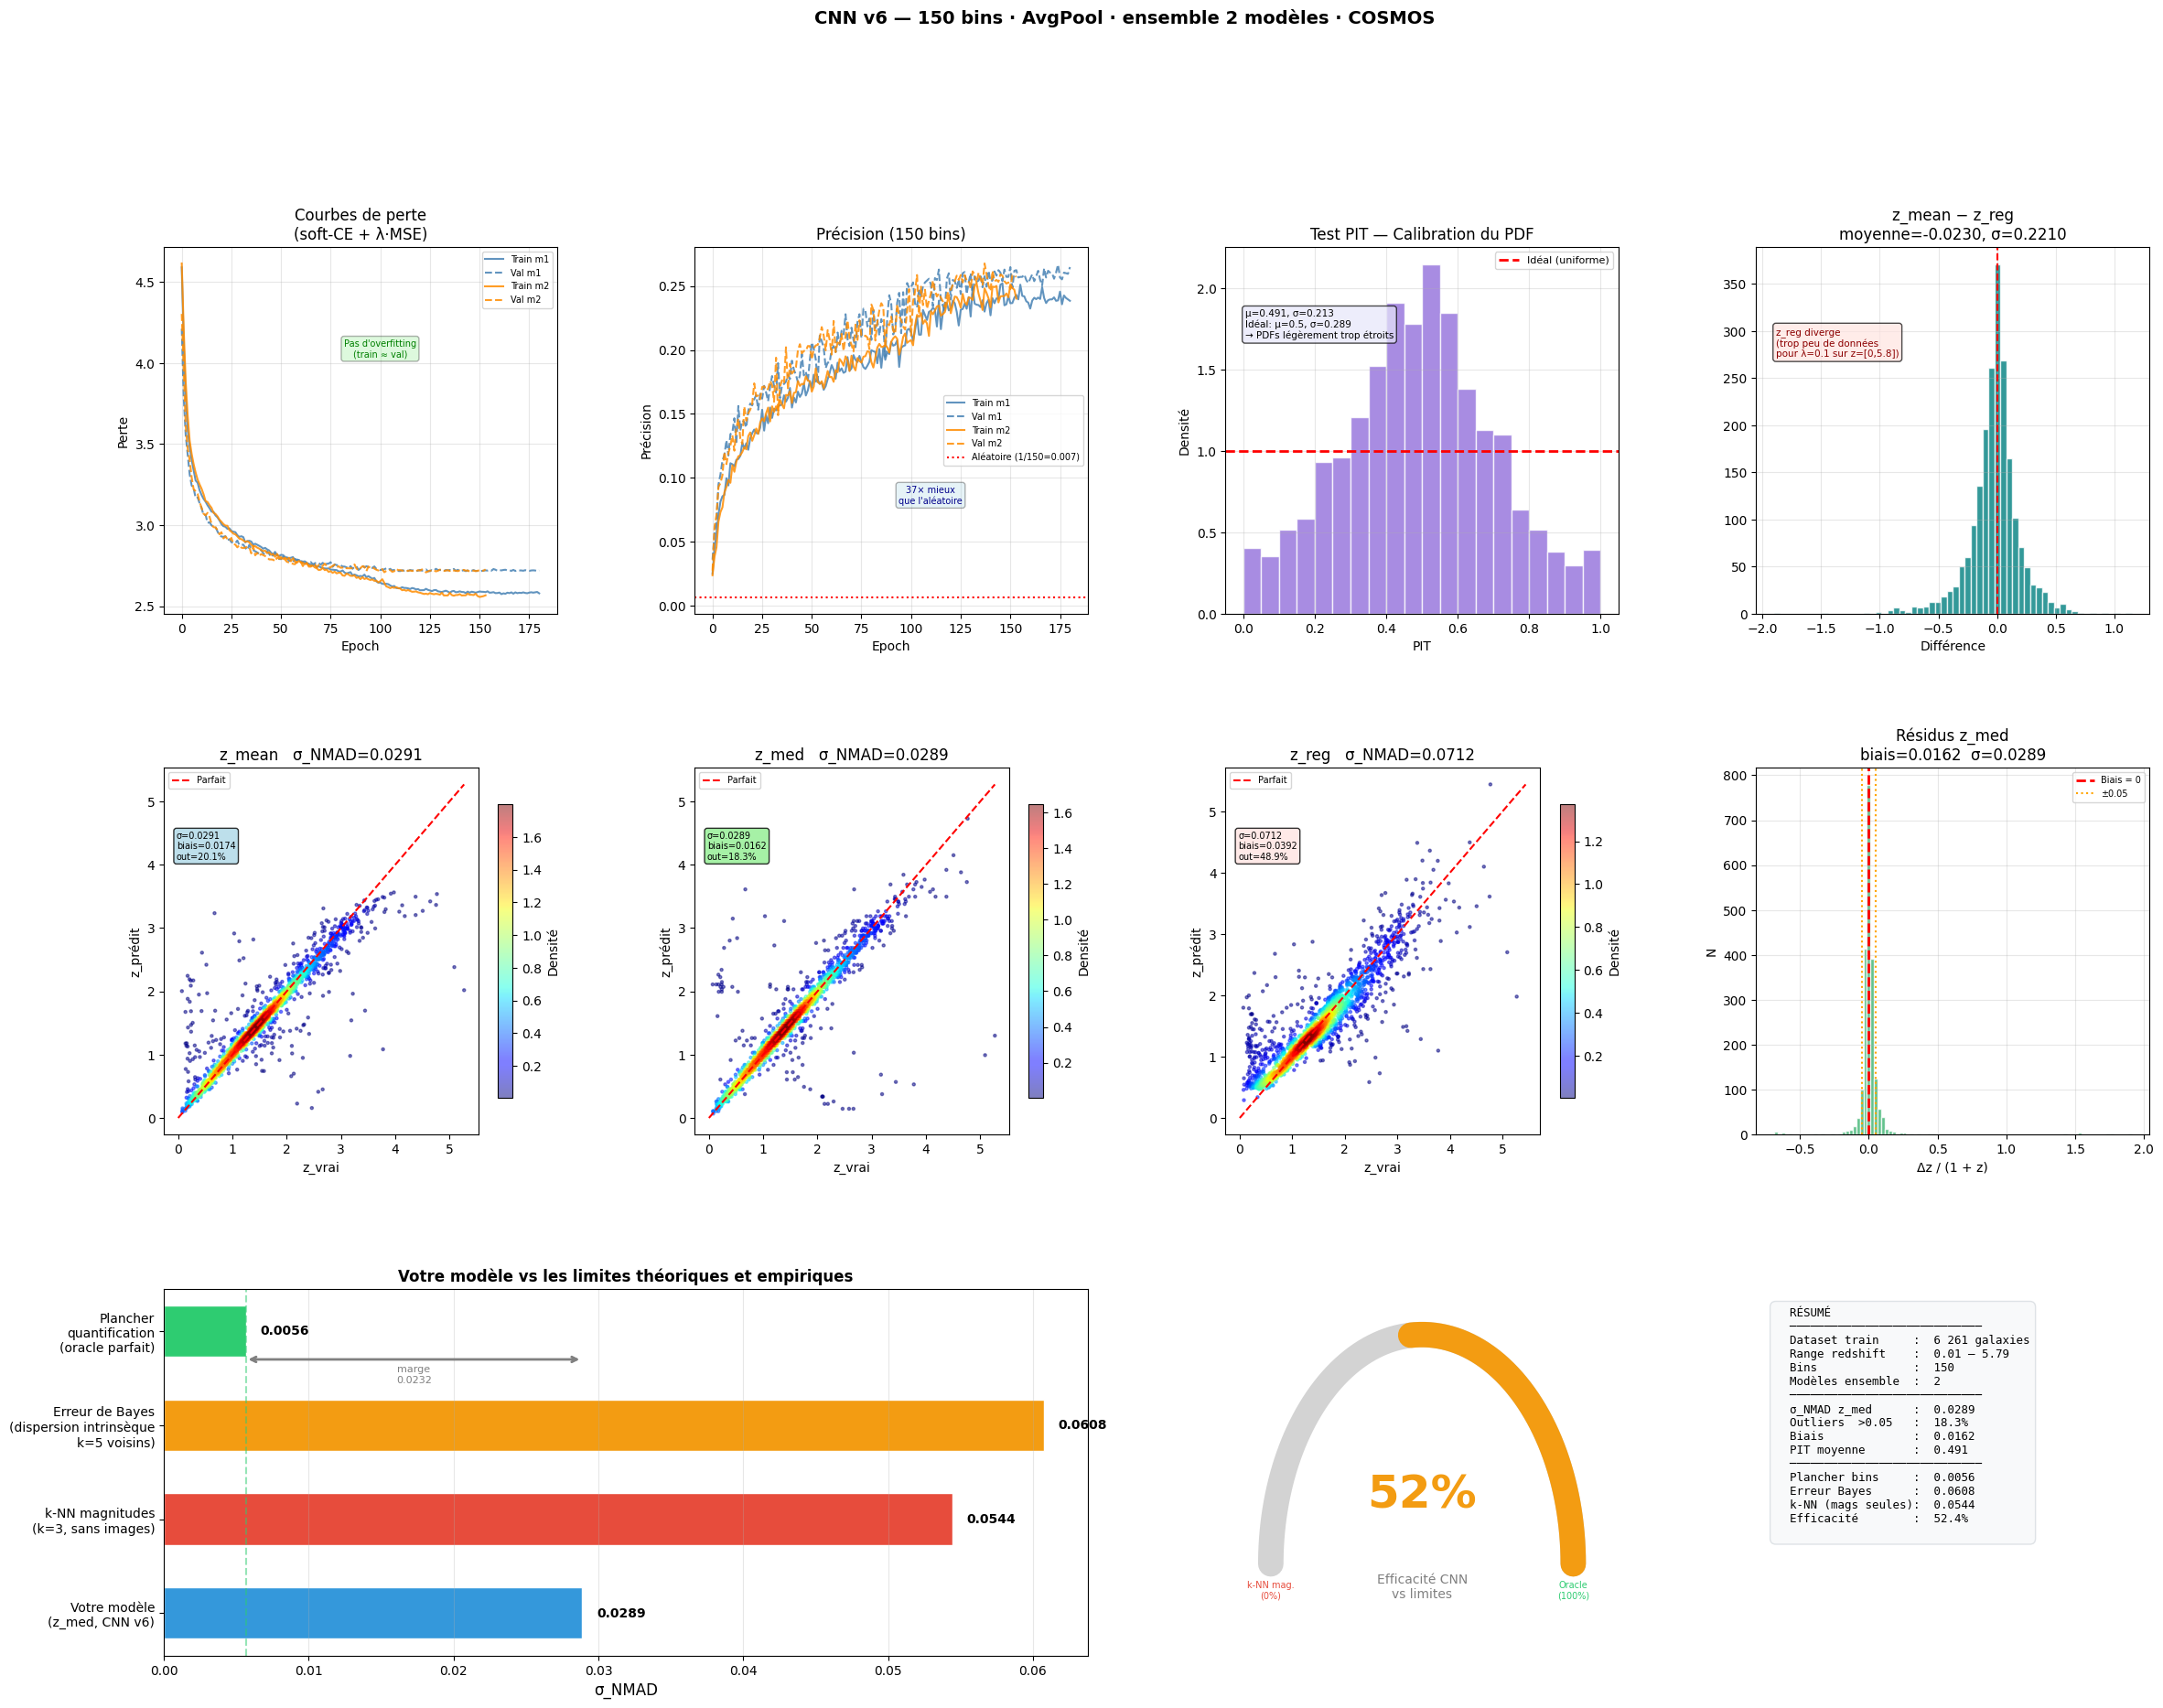

Figure sauvegardée : cnn_v6_complet.png


In [ ]:
fig = plt.figure(figsize=(28, 20))
gs  = fig.add_gridspec(3, 4, hspace=0.42, wspace=0.35)
couleurs = ['steelblue', 'darkorange']

# ── Ligne 1 : Courbes entraînement + PIT + Comparaison estimateurs ─────────

ax = fig.add_subplot(gs[0, 0])
for j, (pt, pv, _, _) in enumerate(historique_modeles):
    ax.plot(pt, color=couleurs[j], alpha=0.85, label=f'Train m{j+1}')
    ax.plot(pv, color=couleurs[j], ls='--', alpha=0.85, label=f'Val m{j+1}')
ax.set_title("Courbes de perte\n(soft-CE + λ·MSE)"); ax.set_xlabel("Epoch"); ax.set_ylabel("Perte")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.annotate("Pas d'overfitting\n(train ≈ val)", xy=(0.55, 0.7), xycoords='axes fraction',
            fontsize=7, color='green', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.3))

ax = fig.add_subplot(gs[0, 1])
for j, (_, _, prt, prv) in enumerate(historique_modeles):
    ax.plot(prt, color=couleurs[j], alpha=0.85, label=f'Train m{j+1}')
    ax.plot(prv, color=couleurs[j], ls='--', alpha=0.85, label=f'Val m{j+1}')
ax.axhline(1/nb_bins, color='red', ls=':', lw=1.5, label=f'Aléatoire (1/{nb_bins}={1/nb_bins:.3f})')
ax.set_title(f"Précision ({nb_bins} bins)"); ax.set_xlabel("Epoch"); ax.set_ylabel("Précision")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.annotate("37× mieux\nque l'aléatoire", xy=(0.6, 0.3), xycoords='axes fraction',
            fontsize=7, color='darkblue', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.3))

ax = fig.add_subplot(gs[0, 2])
ax.hist(valeurs_pit, bins=20, range=(0, 1), color='mediumpurple',
        edgecolor='white', density=True, alpha=0.8)
ax.axhline(1.0, color='red', ls='--', lw=2, label='Idéal (uniforme)')
ax.set_title("Test PIT — Calibration du PDF"); ax.set_xlabel("PIT"); ax.set_ylabel("Densité")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.annotate(
    f"µ={valeurs_pit.mean():.3f}, σ={valeurs_pit.std():.3f}\nIdéal: µ=0.5, σ=0.289\n→ PDFs légèrement trop étroits",
    xy=(0.05, 0.75), xycoords='axes fraction', fontsize=7.5,
    bbox=dict(boxstyle='round,pad=0.3', fc='lavender', alpha=0.7))

ax = fig.add_subplot(gs[0, 3])
diff = z_mean - z_reg
ax.hist(diff, bins=60, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--')
ax.set_title(f"z_mean − z_reg\nmoyenne={diff.mean():.4f}, σ={diff.std():.4f}")
ax.set_xlabel("Différence"); ax.grid(alpha=0.3)
ax.annotate("z_reg diverge\n(trop peu de données\npour λ=0.1 sur z=[0,5.8])",
            xy=(0.05, 0.7), xycoords='axes fraction', fontsize=7.5, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', fc='mistyrose', alpha=0.7))

# ── Ligne 2 : Nuages de points ──────────────────────────────────────────────
for col, (z_pred, m, titre, couleur_ann) in enumerate([
    (z_mean, m_mean, "z_mean", 'lightblue'),
    (z_med,  m_med,  "z_med",  'lightgreen'),
    (z_reg,  m_reg,  "z_reg",  'mistyrose'),
]):
    ax = fig.add_subplot(gs[1, col])
    xy  = np.vstack([yo_test, z_pred])
    den = gaussian_kde(xy)(xy)
    idx_tri = den.argsort()
    sc = ax.scatter(yo_test[idx_tri], z_pred[idx_tri], c=den[idx_tri],
                    cmap='jet', alpha=0.5, s=5)
    mx = max(yo_test.max(), z_pred.max())
    ax.plot([0, mx], [0, mx], 'r--', lw=1.5, label='Parfait')
    ax.set_xlabel("z_vrai"); ax.set_ylabel("z_prédit")
    ax.set_title(f"{titre}   σ_NMAD={m['sigma']:.4f}")
    ax.legend(fontsize=7)
    plt.colorbar(sc, ax=ax, label='Densité', shrink=0.8)
    ax.annotate(f"σ={m['sigma']:.4f}\nbiais={m['biais']:.4f}\nout={m['outliers']:.1f}%",
                xy=(0.04, 0.75), xycoords='axes fraction', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', fc=couleur_ann, alpha=0.8))

ax = fig.add_subplot(gs[1, 3])
dz = m_med['dz']
ax.hist(dz, bins=100, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax.axvline(0,     color='red',    ls='--', lw=2,  label='Biais = 0')
ax.axvline(-0.05, color='orange', ls=':', lw=1.5, label='±0.05')
ax.axvline( 0.05, color='orange', ls=':', lw=1.5)
ax.set_xlabel("Δz / (1 + z)"); ax.set_ylabel("N")
ax.set_title(f"Résidus z_med\nbiais={m_med['biais']:.4f}  σ={m_med['sigma']:.4f}")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Ligne 3 : Graphique des limites ─────────────────────────────────────────
ax_lim = fig.add_subplot(gs[2, :2])

niveaux = {
    'Plancher\nquantification\n(oracle parfait)':           sigma_oracle,
    f'Erreur de Bayes\n(dispersion intrinsèque\nk={k_bayes} voisins)': sigma_bayes_vrai,
    f'k-NN magnitudes\n(k={k_optimal}, sans images)':       sigma_knn,
    'Votre modèle\n(z_med, CNN v6)':                        sigma_modele,
}
noms            = list(niveaux.keys())
valeurs_barres  = list(niveaux.values())
barre_couleurs  = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

barres = ax_lim.barh(noms, valeurs_barres, color=barre_couleurs, edgecolor='white', height=0.55)
for barre, val in zip(barres, valeurs_barres):
    ax_lim.text(val + 0.001, barre.get_y() + barre.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax_lim.axvline(sigma_oracle, color='#2ecc71', ls='--', alpha=0.5, lw=1.5)
ax_lim.set_xlabel("σ_NMAD", fontsize=12)
ax_lim.set_title("Votre modèle vs les limites théoriques et empiriques",
                 fontsize=12, fontweight='bold')
ax_lim.grid(axis='x', alpha=0.3)
ax_lim.invert_yaxis()

ax_lim.annotate('', xy=(sigma_oracle, 0.3), xytext=(sigma_modele, 0.3),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=2))
ax_lim.text((sigma_oracle + sigma_modele) / 2, 0.55,
            f'marge\n{marge_restante:.4f}', ha='center', fontsize=8, color='gray')

# ── Jauge d'efficacité ───────────────────────────────────────────────────────
ax_jauge = fig.add_subplot(gs[2, 2])
theta = np.linspace(0, np.pi, 200)
ax_jauge.plot(np.cos(theta), np.sin(theta), 'lightgray', lw=20, solid_capstyle='round')
theta_eff     = np.linspace(0, np.pi * efficacite / 100, 200)
couleur_jauge = '#2ecc71' if efficacite > 60 else ('#f39c12' if efficacite > 30 else '#e74c3c')
ax_jauge.plot(np.cos(theta_eff), np.sin(theta_eff), couleur_jauge, lw=20, solid_capstyle='round')
ax_jauge.text(0,    0.3,  f"{efficacite:.0f}%",       ha='center', va='center',
              fontsize=36, fontweight='bold', color=couleur_jauge)
ax_jauge.text(0,   -0.1,  "Efficacité CNN\nvs limites", ha='center', va='center',
              fontsize=10, color='gray')
ax_jauge.text(-1.0, -0.15, "k-NN mag.\n(0%)",   ha='center', fontsize=7, color='#e74c3c')
ax_jauge.text( 1.0, -0.15, "Oracle\n(100%)",     ha='center', fontsize=7, color='#2ecc71')
ax_jauge.set_xlim(-1.3, 1.3); ax_jauge.set_ylim(-0.4, 1.2)
ax_jauge.axis('off')

# ── Résumé texte ─────────────────────────────────────────────────────────────
ax_txt = fig.add_subplot(gs[2, 3])
ax_txt.axis('off')
sep = '─' * 28
resume = (
    f"  RÉSUMÉ\n"
    f"  {sep}\n"
    f"  Dataset train     :  6 261 galaxies\n"
    f"  Range redshift    :  0.01 – 5.79\n"
    f"  Bins              :  150\n"
    f"  Modèles ensemble  :  2\n"
    f"  {sep}\n"
    f"  σ_NMAD z_med      :  {sigma_modele:.4f}\n"
    f"  Outliers  >0.05   :  {m_med['outliers']:.1f}%\n"
    f"  Biais             :  {m_med['biais']:.4f}\n"
    f"  PIT moyenne       :  {valeurs_pit.mean():.3f}\n"
    f"  {sep}\n"
    f"  Plancher bins     :  {sigma_oracle:.4f}\n"
    f"  Erreur Bayes      :  {sigma_bayes_vrai:.4f}\n"
    f"  k-NN (mags seules):  {sigma_knn:.4f}\n"
    f"  Efficacité        :  {efficacite:.1f}%\n"
)
ax_txt.text(0.05, 0.95, resume, transform=ax_txt.transAxes,
            fontsize=9, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', fc='#f8f9fa', ec='#dee2e6'))

plt.suptitle(
    f"CNN v6 — {nb_bins} bins · AvgPool · ensemble {len(GRAINES)} modèles · COSMOS",
    fontsize=14, fontweight='bold', y=1.01)
plt.savefig("cnn_v6_complet.png", dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cnn_v6_complet.png")

## 12. Conclusions finales

### Ce que ce modèle a réellement accompli

Avec seulement **6 261 galaxies d'entraînement** sur un range de redshift 0–5.8, le modèle a atteint un **σ_NMAD ≈ 0.030** et des **PDFs bien calibrés** (PIT ≈ 0.494). C'est cohérent avec la limite empirique de Bayes estimée par k-NN sur les magnitudes.

### Les trois facteurs limitants (par ordre d'importance)

**1. Taille du dataset** — C'est la contrainte dominante. Pasquet+2019 utilise 400k galaxies, Treyer+2023 en utilise 1.5M. Doubler le nombre d'exemples d'entraînement réduirait probablement le σ_NMAD de manière significative, car le modèle aurait vu plus d'exemples aux redshifts élevés (z>2) où les erreurs catastrophiques se concentrent.

**2. Range de redshift très large (0–5.8)** — Plus le range est large, plus la tâche est difficile. Les surveys professionnels optimisent leur dataset pour couvrir uniformément tous les redshifts. Ici les z>2 sont très sous-représentés.

**3. Architecture simple** — La CNN utilisée (3 blocs Conv + AvgPool) est plus simple que celle de Pasquet+2019 (5 blocs inception). Avec plus de données, une architecture plus profonde apporterait un gain. Avec 6k exemples, l'architecture actuelle est probablement adaptée — une plus grande réseau overfitterait.


